<a href="https://colab.research.google.com/github/ranajanajreh3-ship-it/data_analysis/blob/main/Gen%20AI%20media%20performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import kagglehub

In [ ]:
import kagglehub as kh
path = kagglehub.dataset_download("algozee/genai-media-performance-dataset-2026")

100%|██████████| 862k/862k [00:00<00:00, 75.9MB/s]

Extracting files...


In [ ]:
import os

In [ ]:
print(os.listdir(path))
file_path = os.path.join(path,'GenAI_Media_Perf_2026.csv.csv')
df = pd.read_csv(file_path)
print(df.info())

['GenAI_Media_Perf_2026.csv.csv']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   content_id           30000 non-null  object 
 1   platform             30000 non-null  object 
 2   content_type         30000 non-null  object 
 3   ai_tool_used         30000 non-null  object 
 4   ai_type              30000 non-null  object 
 5   duration_seconds     30000 non-null  int64  
 6   production_cost_usd  30000 non-null  float64
 7   views                30000 non-null  int64  
 8   likes                30000 non-null  int64  
 9   comments             30000 non-null  int64  
 10  shares               30000 non-null  int64  
 11  engagement_rate      30000 non-null  float64
 12  watch_time_avg_sec   30000 non-null  float64
 13  retention_rate       30000 non-null  float64
 14  revenue_usd          30000 non-null  float64
dtypes:

In [ ]:
print(df.head())

  content_id platform content_type   ai_tool_used              ai_type  \
0  ACC000001   TikTok        Short  Adobe Firefly        Text-to-video   
1  ACC000002   TikTok        Short         HeyGen         Avatar video   
2  ACC000003  YouTube        Short       Canva AI  AI-assisted editing   
3  ACC000004   TikTok         Reel     InVideo AI  AI-assisted editing   
4  ACC000005   TikTok        Short           Pika        Text-to-video   

   duration_seconds  production_cost_usd  views  likes  comments  shares  \
0                20                15.93  10529    474        52      39   
1                12                23.21  10058    451        64      44   
2                46                14.60   4349    187        23      10   
3                27                10.07  23968   1259       140     236   
4                52                16.85   3290    118        22      35   

   engagement_rate  watch_time_avg_sec  retention_rate  revenue_usd  
0           0.0537          

In [ ]:
print(df.isnull().sum())

content_id             0
platform               0
content_type           0
ai_tool_used           0
ai_type                0
duration_seconds       0
production_cost_usd    0
views                  0
likes                  0
comments               0
shares                 0
engagement_rate        0
watch_time_avg_sec     0
retention_rate         0
revenue_usd            0
dtype: int64


In [ ]:
df = df.drop_duplicates()
print(df)

      content_id   platform content_type   ai_tool_used              ai_type  \
0      ACC000001     TikTok        Short  Adobe Firefly        Text-to-video   
1      ACC000002     TikTok        Short         HeyGen         Avatar video   
2      ACC000003    YouTube        Short       Canva AI  AI-assisted editing   
3      ACC000004     TikTok         Reel     InVideo AI  AI-assisted editing   
4      ACC000005     TikTok        Short           Pika        Text-to-video   
...          ...        ...          ...            ...                  ...   
29995  ACC029996  Instagram         Reel     InVideo AI  AI-assisted editing   
29996  ACC029997     TikTok        Short      CapCut AI        Text-to-video   
29997  ACC029998     TikTok         Reel           Pika       Image-to-video   
29998  ACC029999    YouTube        Short     InVideo AI       Image-to-video   
29999  ACC030000     TikTok        Short         Runway       Image-to-video   

       duration_seconds  production_cos

In [ ]:
ai_performans = df.groupby('ai_tool_used')['views'].sum().sort_values(ascending=True)
print(ai_performans)

ai_tool_used
Adobe Firefly    43582766
Synthesia        47734146
HeyGen           51061959
Pika             59544839
InVideo AI       61530442
Canva AI         62942912
Runway           83115946
CapCut AI        89234974
Name: views, dtype: int64


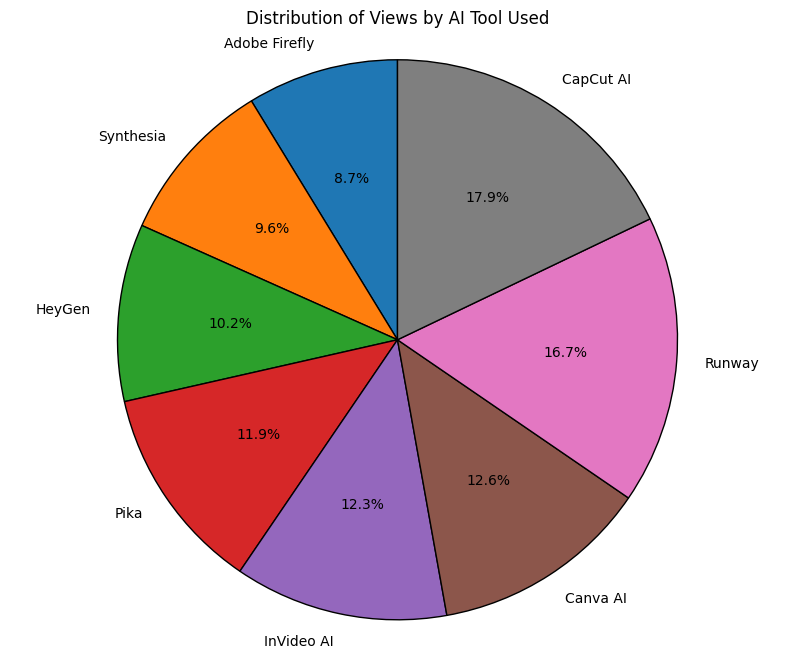

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for the pie chart
labels = ai_performans.index
sizes = ai_performans.values

# Create the pie chart
fig , ax = plt.subplots(figsize=(10, 8)) # Set a good figure size
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Views by AI Tool Used')
plt.show()

In [ ]:
platform_eng = df.groupby('platform')['engagement_rate'].mean().sort_values(ascending=True)
print(platform_eng)

platform
YouTube      0.044879
Instagram    0.062184
TikTok       0.073256
Name: engagement_rate, dtype: float64


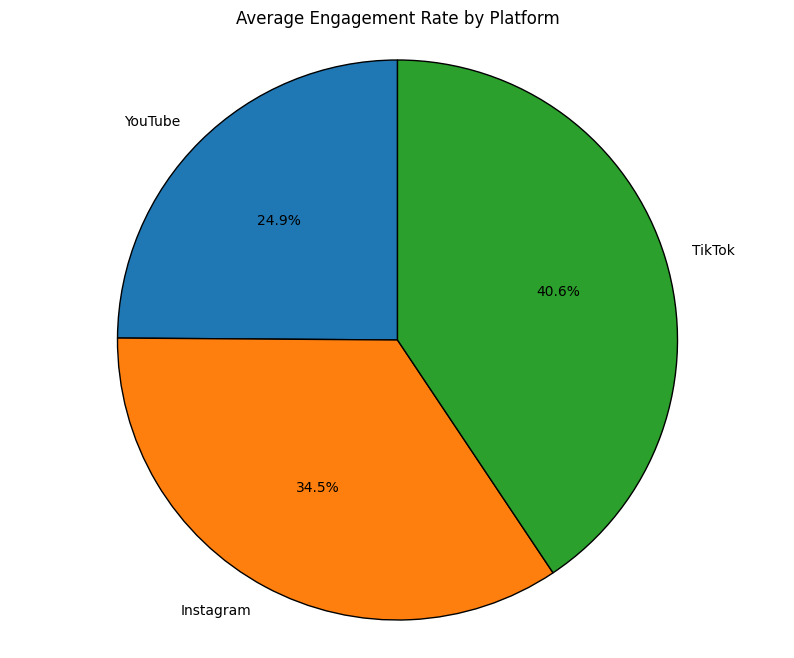

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for the pie chart
labels = platform_eng.index
sizes = platform_eng.values

# Create the pie chart
fig, ax = plt.subplots(figsize=(10, 8)) # Set a good figure size
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Average Engagement Rate by Platform')
plt.show()

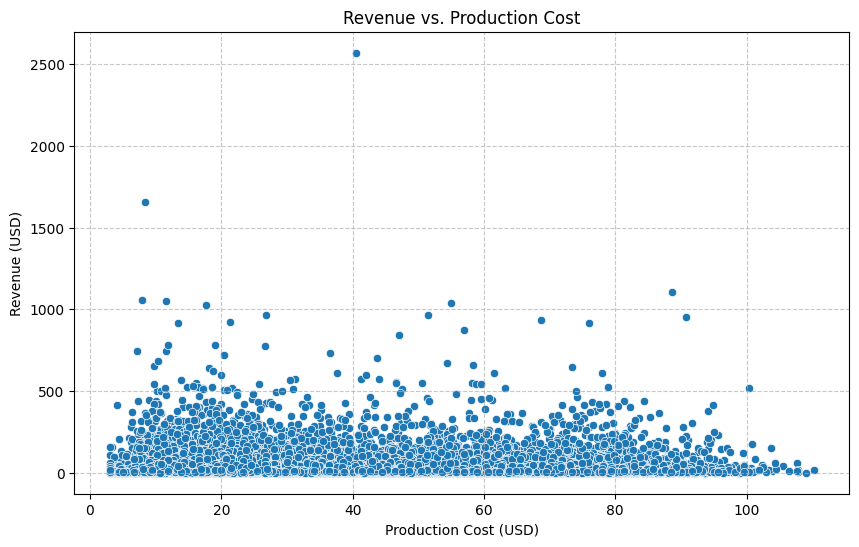

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot
fig, ax = plt.subplots(figsize=(10, 6)) # Set a good figure size
sns.scatterplot(x='production_cost_usd', y='revenue_usd', data=df, ax=ax)
plt.title('Revenue vs. Production Cost')
plt.xlabel('Production Cost (USD)')
plt.ylabel('Revenue (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:

pivot_analysis = df.pivot_table(index='platform',
                               columns='ai_tool_used',
                               values='engagement_rate',
                               aggfunc='mean')

print("--- Engagement Rate: Platform vs. Technology ---")
print(pivot_analysis)

--- Engagement Rate: Platform vs. Technology ---
ai_tool_used  Adobe Firefly  Canva AI  CapCut AI    HeyGen  InVideo AI  \
platform                                                                 
Instagram          0.062241  0.062487   0.061892  0.062004    0.062291   
TikTok             0.072640  0.073437   0.073199  0.073357    0.072949   
YouTube            0.045080  0.044905   0.044800  0.045290    0.044940   

ai_tool_used      Pika    Runway  Synthesia  
platform                                     
Instagram     0.061576  0.062164   0.063049  
TikTok        0.073791  0.073626   0.072646  
YouTube       0.044514  0.045029   0.044520  


In [ ]:

max_value = pivot_analysis.values.max()
max_index = pivot_analysis.stack().idxmax()
print(max_value)
print(max_index)





0.07379100156494522
('TikTok', 'Pika')


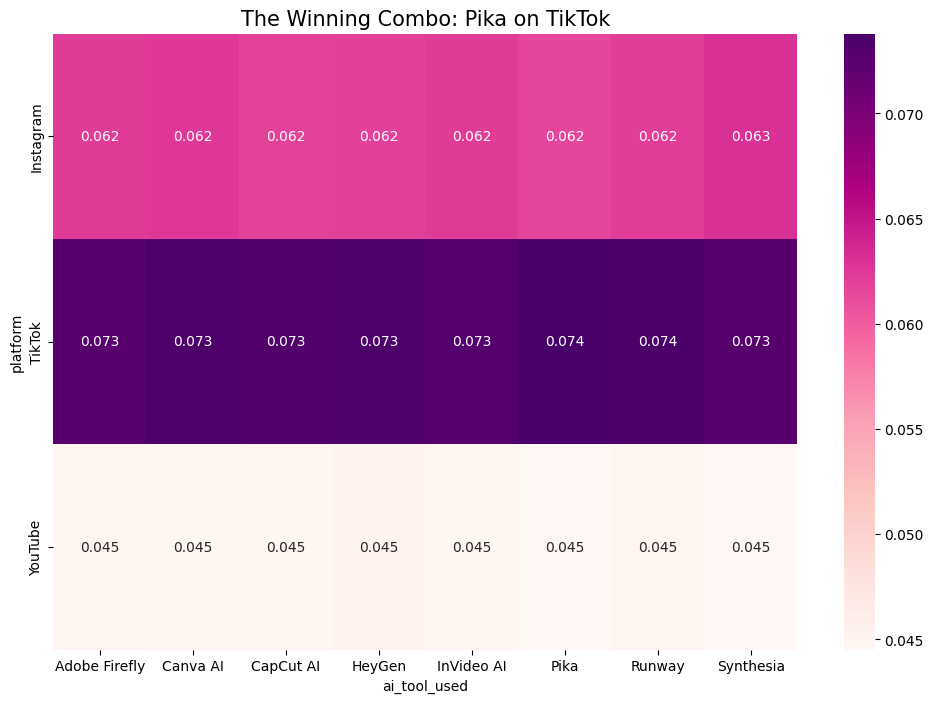

--- Final Project Insight ---
The highest engagement is achieved by Pika on TikTok with 0.0738 rate.
Note: Canva AI performs exceptionally well on Instagram compared to other design tools.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Dataset
df = pd.read_csv(file_path)

# 2. Data Cleaning
df.drop_duplicates(inplace=True)
df['engagement_rate'] = df['engagement_rate'].fillna(df['engagement_rate'].mean())

# 3. Pivot Table Analysis (Platform vs Tool)
pivot_analysis = df.pivot_table(index='platform',
                               columns='ai_tool_used',
                               values='engagement_rate',
                               aggfunc='mean')

# 4. Finding the Ultimate Winners
max_val = pivot_analysis.values.max()
max_idx = pivot_analysis.stack().idxmax()
platform_win, tool_win = max_idx

# 5. Visualizing the Results (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_analysis, annot=True, cmap='RdPu', fmt='.3f')
plt.title(f'The Winning Combo: {tool_win} on {platform_win}', fontsize=15)
plt.show()

# Print Final Insights
print(f"--- Final Project Insight ---")
print(f"The highest engagement is achieved by {tool_win} on {platform_win} with {max_val:.4f} rate.")
print(f"Note: Canva AI performs exceptionally well on Instagram compared to other design tools.")

In [ ]:
df['cost_per_engagement'] = df['production_cost_usd']/(df['engagement_rate']*100)
roi_analysis = df.groupby('ai_tool_used')['cost_per_engagement'].mean().sort_values(ascending=True)
print(roi_analysis)

ai_tool_used
Canva AI         4.299935
CapCut AI        4.570888
InVideo AI       4.996075
Pika             5.824351
Adobe Firefly    6.023137
Runway           6.386475
Synthesia        6.878715
HeyGen           7.150820
Name: cost_per_engagement, dtype: float64


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Page Configuration
st.set_page_config(page_title="GenAI Media Dashboard 2026", layout="wide")
st.title("🚀 GenAI Media Performance Dashboard")
st.markdown("Explore how AI tools perform across different social platforms and their financial implications.")

# 2. Load Data
# Use the full path derived from the Kagglehub download
df = pd.read_csv('/kaggle/input/genai-media-performance-dataset-2026/GenAI_Media_Perf_2026.csv.csv')

# --- Interactive Filters ---
st.sidebar.header("Filter Options")
all_platforms = df['platform'].unique().tolist()
all_ai_tools = df['ai_tool_used'].unique().tolist()

selected_platform = st.sidebar.multiselect("Select Platform(s)", all_platforms, default=all_platforms)
selected_ai_tool = st.sidebar.multiselect("Select AI Tool(s)", all_ai_tools, default=all_ai_tools)

filtered_df = df[df['platform'].isin(selected_platform) & df['ai_tool_used'].isin(selected_ai_tool)]

if filtered_df.empty:
    st.warning("No data matches the selected filters. Please adjust your selections.")
else:
    # --- KPIs ---
    st.subheader("Key Performance Indicators (KPIs)")
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Views", f"{filtered_df['views'].sum():,}")
    col2.metric("Avg Engagement Rate", f"{filtered_df['engagement_rate'].mean():.2%}")
    col3.metric("Total Production Cost", f"${filtered_df['production_cost_usd'].sum():,.2f}")
    col4.metric("Total Revenue", f"${filtered_df['revenue_usd'].sum():,.2f}")

    st.markdown("---")

    # --- Visualizations ---

    # Row 1: AI Tool Performance (Views) and Platform Engagement
    st.subheader("Performance Overviews")
    vis_col1, vis_col2 = st.columns(2)

    with vis_col1:
        st.write("### Distribution of Views by AI Tool Used")
        ai_performans = filtered_df.groupby('ai_tool_used')['views'].sum().sort_values(ascending=False)
        if not ai_performans.empty:
            fig_ai_views, ax_ai_views = plt.subplots(figsize=(8, 6))
            ax_ai_views.pie(ai_performans.values, labels=ai_performans.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
            ax_ai_views.axis('equal')
            ax_ai_views.set_title('Distribution of Views by AI Tool Used') # Add title to the plot
            st.pyplot(fig_ai_views)
        else:
            st.info("No AI tool views data for the selected filters.")


    with vis_col2:
        st.write("### Average Engagement Rate by Platform")
        platform_eng = filtered_df.groupby('platform')['engagement_rate'].mean().sort_values(ascending=False)
        if not platform_eng.empty:
            fig_platform_eng, ax_platform_eng = plt.subplots(figsize=(8, 6))
            ax_platform_eng.pie(platform_eng.values, labels=platform_eng.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
            ax_platform_eng.axis('equal')
            ax_platform_eng.set_title('Average Engagement Rate by Platform') # Add title to the plot
            st.pyplot(fig_platform_eng)
        else:
            st.info("No platform engagement data for the selected filters.")

    st.markdown("---")

    # Row 2: Revenue vs. Production Cost & Cost per Engagement
    st.subheader("Financial Analysis")
    vis_col3, vis_col4 = st.columns(2)

    with vis_col3:
        st.write("### Revenue vs. Production Cost")
        if not filtered_df.empty and not filtered_df[['production_cost_usd', 'revenue_usd']].isnull().any().any():
            fig_scatter, ax_scatter = plt.subplots(figsize=(8, 6))
            sns.scatterplot(x='production_cost_usd', y='revenue_usd', data=filtered_df, ax=ax_scatter)
            ax_scatter.set_xlabel('Production Cost (USD)')
            ax_scatter.set_ylabel('Revenue (USD)')
            ax_scatter.grid(True, linestyle='--', alpha=0.7)
            ax_scatter.set_title('Revenue vs. Production Cost') # Add title to the plot
            st.pyplot(fig_scatter)
        else:
            st.info("No data for Revenue vs. Production Cost or contains missing values.")

    with vis_col4:
        st.write("### Average Cost per Engagement by AI Tool")
        # Ensure 'cost_per_engagement' exists or calculate it if needed
        temp_df_cpe = filtered_df.copy() # Avoid modifying original filtered_df if not strictly necessary
        if 'cost_per_engagement' not in temp_df_cpe.columns:
            # Handle potential division by zero for engagement_rate
            temp_df_cpe['cost_per_engagement'] = temp_df_cpe.apply(
                lambda row: row['production_cost_usd'] / (row['engagement_rate'] * 100)
                if row['engagement_rate'] > 0 else 0, axis=1
            )
        # Filter out rows where cost_per_engagement might be 0 due to 0 engagement_rate
        temp_df_cpe = temp_df_cpe[temp_df_cpe['cost_per_engagement'] > 0]

        if not temp_df_cpe.empty:
            roi_analysis = temp_df_cpe.groupby('ai_tool_used')['cost_per_engagement'].mean().sort_values(ascending=True)
            fig_roi, ax_roi = plt.subplots(figsize=(8, 6))
            sns.barplot(x=roi_analysis.index, y=roi_analysis.values, ax=ax_roi, palette='viridis')
            ax_roi.set_xlabel('AI Tool Used')
            ax_roi.set_ylabel('Average Cost per Engagement')
            ax_roi.tick_params(axis='x', rotation=45)
            ax_roi.set_title('Average Cost per Engagement by AI Tool') # Add title to the plot
            st.pyplot(fig_roi)
        else:
            st.info("No valid data for Cost per Engagement.")

    st.markdown("---")

    # Row 3: Heatmap
    st.subheader("AI Tool & Platform Engagement Heatmap")
    if not filtered_df.empty:
        pivot_analysis = filtered_df.pivot_table(index='platform',
                                            columns='ai_tool_used',
                                            values='engagement_rate',
                                            aggfunc='mean')
        if not pivot_analysis.empty and not pivot_analysis.isnull().all().all():
            fig_heatmap, ax_heatmap = plt.subplots(figsize=(10, 7))
            sns.heatmap(pivot_analysis, annot=True, cmap='RdPu', fmt='.3f', linewidths=.5, ax=ax_heatmap)
            ax_heatmap.set_title('Average Engagement Rate: Platform vs. AI Tool Used')
            st.pyplot(fig_heatmap)
        else:
            st.info("No data for heatmap with current filters or all values are NaN.")
    else:
        st.info("No data for heatmap with current filters.")

    st.markdown("---")

    # Raw Data Display
    if st.checkbox("Show Raw Data"):
        st.write(filtered_df)


Writing app.py


In [ ]:
!pip install pyngrok --quiet
from pyngrok import ngrok

# Replace 'YOUR_NGROK_AUTH_TOKEN' with your actual ngrok authentication token
# You can get one from your ngrok dashboard after signing up (it's free)
ngrok.set_auth_token("3CSNmMuv86YOQaHXSKpEFpJGlb7_5eZnuaU1iuzbasmnnmjaT")
# UNCOMMENT THE LINE ABOVE AND REPLACE 'YOUR_NGROK_AUTH_TOKEN' WITH YOUR ACTUAL TOKEN

# Kill any existing ngrok tunnels to free up resources
ngrok.kill()

!pip install streamlit --quiet

# Run Streamlit in the background
!nohup streamlit run app.py &

# Open a ngrok tunnel to the Streamlit app's port (default is 8501)
public_url = ngrok.connect(addr='8501')
print(f'Streamlit App URL: {public_url}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 86.2 MB/s eta 0:00:00
nohup: appending output to 'nohup.out'
Streamlit App URL: NgrokTunnel: "https://padding-tinfoil-pesticide.ngrok-free.dev" -> "http://localhost:8501"
